# 03 - Word2Vec


---

In the previous notebook, we learned TF-IDF.

Although TF-IDF improves word importance, it still cannot understand the meaning of words.

Word2Vec was introduced to solve this problem.

Instead of representing words as counts, Word2Vec represents every word as a dense vector.

## 📜 History

Bag of Words and TF-IDF convert words into numbers.

However, they treat every word as completely independent.

Example:

King

Queen

Man

Woman

These words are related.

But BoW and TF-IDF cannot capture these relationships.

Researchers wanted computers to understand word meaning.

In 2013, researchers at Google introduced **Word2Vec**.

Word2Vec learns word meanings by looking at the surrounding words (context).

This was a major breakthrough in NLP.

## ❌ Limitations of TF-IDF

TF-IDF cannot understand:

- Synonyms
- Context
- Similar meanings
- Relationships between words

Example:

car

automobile

TF-IDF thinks these are completely different words.

Humans know they have nearly the same meaning.

We need a better representation.

This leads to Word Embeddings.

## 💡 Core Idea

Instead of storing word counts,

Word2Vec stores every word as a vector.

Example

King

↓

[0.23, -0.18, 0.71, ...]

Queen

↓

[0.21, -0.15, 0.68, ...]

Similar words have similar vectors.

## 🧠 Sparse vs Dense Representation

### 1. Sparse Representation (Bag of Words)

Bag of Words represents a word using a very large vector where most values are **0** and only a few positions contain meaningful values.

Example vocabulary:

```text
["AI", "Cat", "Dog", "Machine", "Python"]
```

Word: **Dog**

```text
[0, 0, 1, 0, 0]
```

If the vocabulary contains **50,000 words**, the vector may look like:

```text
[0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,...]
```

✅ Only one position is active.

❌ Most values are **0**, so the vector is called **Sparse**.

### Limitation

Bag of Words treats similar words as completely different.

Example:

```text
Dog → [0,0,1,0,0]

Cat → [0,1,0,0,0]
```

Although **Dog** and **Cat** are both animals, their vectors have no similarity.

---

## 2. Dense Representation (Word2Vec)

Word2Vec learns a small vector of real numbers for every word.

Example:

```text
Dog
↓
[0.12, -0.43, 0.78, 0.15]

Cat
↓
[0.10, -0.40, 0.75, 0.18]
```

Notice that both vectors are very similar.

This tells the model that:

```text
Dog ≈ Cat
```

because they have similar meanings.

---

## Why is it called Dense?

Unlike Bag of Words, almost every value contains useful information.

Example:

```text
[0.12, -0.43, 0.78, 0.15]
```

Every number contributes to representing the meaning of the word.

Hence it is called a **Dense Representation**.

---

## Why Dense Representations are Better

✔ Much smaller vectors

✔ Capture semantic meaning

✔ Similar words have similar vectors

✔ Better for Machine Learning and Deep Learning models

✔ Improve tasks like text classification, search, translation, and question answering

---

## Comparison

| Bag of Words (Sparse) | Word2Vec (Dense) |
|------------------------|------------------|
| Mostly zeros | Real-valued numbers |
| Large vector size | Small vector size |
| No semantic meaning | Captures semantic meaning |
| Similar words look different | Similar words have similar vectors |
| Memory inefficient | Memory efficient |

---

## 📌 Key Takeaway

**Sparse Representation** stores words using large vectors with mostly zeros and cannot capture relationships between words.

**Dense Representation** stores words using compact numerical vectors that preserve semantic meaning, making them much more effective for modern NLP and Machine Learning models.

In [ ]:
#Manual embedding examples

import pandas as pd

embeddings = {
    "king":[0.8,0.2],
    "queen":[0.75,0.25],
    "man":[0.9,-0.1],
    "woman":[0.85,0.0],
    "dog":[-0.8,-0.5],
    "cat":[-0.75,-0.45]
}

embedding_df = pd.DataFrame(embeddings).T

embedding_df.columns=["Dimension 1","Dimension 2"]

embedding_df

,Dimension 1,Dimension 2
king,0.80,0.20
queen,0.75,0.25
man,0.90,-0.10
woman,0.85,0.00
dog,-0.80,-0.50
cat,-0.75,-0.45


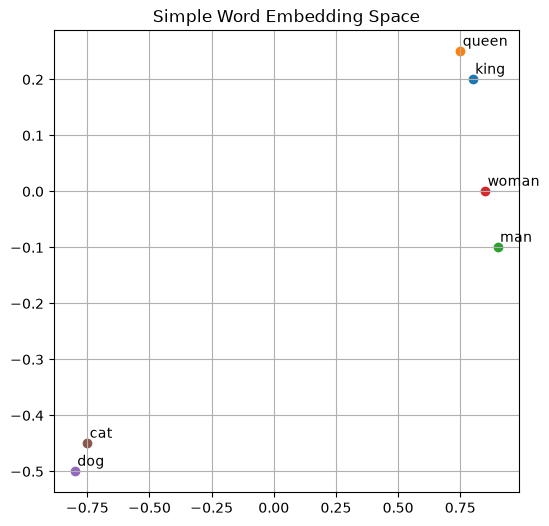

In [ ]:
#visualize word embeddings

import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

for word,vector in embeddings.items():

    plt.scatter(vector[0],vector[1])

    plt.text(vector[0]+0.01,vector[1]+0.01,word)

plt.title("Simple Word Embedding Space")

plt.grid()

plt.show()

## 🧠 How Word2Vec Learns

Word2Vec has two training methods.

### 1. CBOW

Continuous Bag of Words

Predict the center word from surrounding words.

Example

"I love ____"

↓

Predict

AI

---

### 2. Skip-Gram

Given one word,

predict its surrounding words.

Example

AI

↓

Predict

love

learning

future

technology

# Understanding CBOW

In [3]:
sentence = "I love learning AI"

words = sentence.split()

target = words[2]

context = [words[1], words[3]]

print("Context:", context)
print("Target:", target)

Context: ['love', 'AI']
Target: learning


# Understanding Skip-Gram

In [4]:
sentence="I love learning AI"

words=sentence.split()

target=words[2]

context=[words[1],words[3]]

print("Target:",target)

print("Predict Context:",context)

Target: learning
Predict Context: ['love', 'AI']


# Train Your First Word2Vec

In [1]:
from gensim.models import Word2Vec

sentences = [
    ["i","love","ai"],
    ["ai","is","amazing"],
    ["machine","learning","is","interesting"],
    ["deep","learning","uses","neural","networks"],
    ["python","is","great"]
]

model = Word2Vec(
    sentences,
    vector_size=50,
    window=2,
    min_count=1,
    workers=1
)

In [ ]:
#vocabolary

print(model.wv.index_to_key)

['is', 'learning', 'ai', 'great', 'python', 'networks', 'neural', 'uses', 'deep', 'interesting', 'machine', 'amazing', 'love', 'i']


In [3]:
# Word Vector

model.wv["ai"]

array([-0.01723938,  0.00733148,  0.01037977,  0.01148388,  0.01493384,
       -0.01233535,  0.00221123,  0.01209456, -0.0056801 , -0.01234705,
       -0.00082045, -0.0167379 , -0.01120002,  0.01420908,  0.00670508,
        0.01445134,  0.01360049,  0.01506148, -0.00757831, -0.00112361,
        0.00469675, -0.00903806,  0.01677746, -0.01971633,  0.01352928,
        0.00582883, -0.00986566,  0.00879638, -0.00347915,  0.01342277,
        0.0199297 , -0.00872489, -0.00119868, -0.01139127,  0.00770164,
        0.00557325,  0.01378215,  0.01220219,  0.01907699,  0.01854683,
        0.01579614, -0.01397901, -0.01831173, -0.00071151, -0.00619968,
        0.01578863,  0.01187715, -0.00309133,  0.00302193,  0.00358008],
      dtype=float32)

In [4]:
#Most similar word
model.wv.most_similar("learning")

[('python', 0.12496910244226456),
 ('love', 0.08058696985244751),
 ('neural', 0.07405462861061096),
 ('is', 0.04236598312854767),
 ('networks', 0.01829960010945797),
 ('ai', 0.01109987497329712),
 ('interesting', 0.0013611827744171023),
 ('i', -0.011991335079073906),
 ('amazing', -0.10941106826066971),
 ('deep', -0.11908881366252899)]

# Cosine Similarity

In [5]:
similarity = model.wv.similarity(
    "learning",
    "ai"
)

print(similarity)

0.0110999


## ✅ Advantages

- Understands semantic meaning
- Similar words have similar vectors
- Dense representation
- Much smaller vectors than BoW
- Foundation for many later NLP models